# U-Net Baseline vs sMoE U-Net — Comparison Notebook
## Replicating Paper Table 1: Standard U-Net (ODS 0.7437) vs sMoE U-Net (ODS 0.7628)

This notebook trains **both** models under identical conditions (same dataset, same loss,
same training loop) and produces a side-by-side comparison of:
- Quantitative metrics: ODS, OIS, AP
- Precision-Recall curves
- Visual edge detection quality
- Training curve comparison

**Pipeline is identical to the paper** — the only change is removing the sMoE blocks and TSK head.


In [1]:
# ============================================================
# CELL 1: Setup
# ============================================================
import torch, os, sys
print("Python:", sys.version)
print("Torch :", torch.__version__)
print("CUDA  :", torch.cuda.is_available())
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Torch : 2.10.0+cu128
CUDA  : True
Device: cuda


In [2]:
# ============================================================
# CELL 2: Install Dependencies
# ============================================================
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q numpy matplotlib opencv-python-headless scipy Pillow tqdm scikit-learn
print("✅ Dependencies installed")


✅ Dependencies installed


In [4]:
# ============================================================
# CELL 3: Imports & Config
# ============================================================
import os, time, warnings, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
from tqdm import tqdm
import scipy.io

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from sklearn.metrics import average_precision_score, precision_recall_curve

warnings.filterwarnings('ignore')
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
if DEVICE.type == 'cuda':
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True

# Shared hyperparameters (Paper §3.1) — IDENTICAL for both models
BATCH_SIZE    = 4
LEARNING_RATE = 1e-4
WEIGHT_DECAY  = 1e-5
LAMBDA_BCE    = 0.5
IMG_SIZE      = 256
MAX_EPOCHS    = 120
PATIENCE      = 15
CLIP_GRAD     = 5.0

WORK_DIR = '/content/drive/MyDrive/unet_vs_smoe'
os.makedirs(WORK_DIR, exist_ok=True)
print("✅ Config ready")


✅ Config ready


In [5]:
# ============================================================
# CELL 4: Download BSDS500 from GitHub
# ============================================================
print("Downloading BSDS500 dataset from GitHub...")

import os
import subprocess

# Method 1: Using git clone (recommended for full repo access)
github_repo = "https://github.com/BIDS/BSDS500.git"
target_dir = "/content/BSDS500"

if not os.path.exists(target_dir):
    print(f"Cloning repository from {github_repo}...")
    result = subprocess.run(["git", "clone", github_repo, target_dir],
                          capture_output=True, text=True)
    if result.returncode == 0:
        print("✅ Repository cloned successfully")
    else:
        print(f"❌ Git clone failed: {result.stderr}")
        print("Trying alternative method...")
else:
    print(f"Directory {target_dir} already exists")

# Check the data directory structure
data_dir = "/content/BSDS500/BSDS500/data"
if os.path.exists(data_dir):
    print(f"\n✅ BSDS500 data found at: {data_dir}")
    print("\nContents:")
    for item in os.listdir(data_dir)[:10]:  # Show first 10 items
        print(f"  - {item}")
    if len(os.listdir(data_dir)) > 10:
        print(f"  ... and {len(os.listdir(data_dir)) - 10} more items")
else:
    print(f"\n⚠️ Data directory not found at expected path")
    print("Searching for data folder...")
    for root, dirs, files in os.walk("/content/BSDS500"):
        if "data" in dirs:
            data_path = os.path.join(root, "data")
            print(f"✅ Found data at: {data_path}")
            break

print("\n📁 Dataset structure:")
!ls -la /content/BSDS500/BSDS500/ 2>/dev/null || ls -la /content/BSDS500/

Cloning repository from https://github.com/BIDS/BSDS500.git...
✅ Repository cloned successfully

✅ BSDS500 data found at: /content/BSDS500/BSDS500/data

Contents:
  - groundTruth
  - images

📁 Dataset structure:
total 16
drwxr-xr-x 4 root root 4096 May  9 19:01 .
drwxr-xr-x 7 root root 4096 May  9 19:01 ..
drwxr-xr-x 4 root root 4096 May  9 19:01 data
drwxr-xr-x 6 root root 4096 May  9 19:01 ucm2


Checking BSDS500 dataset structure
✅ Data root found: /content/BSDS500/BSDS500/data
  ✅ train: 200 images
     train: 200 ground truth files
  ✅ val: 100 images
     val: 100 ground truth files
  ✅ test: 200 images
     test: 200 ground truth files

Creating BSDS500 Datasets
BSDS500 [train]: 200 images
BSDS500 [val]: 100 images
BSDS500 [test]: 200 images

DataLoader Summary
Train batches: 50 (total images: 200)
Val batches:   25 (total images: 100)
Test batches:  200 (total images: 200)

Testing data loading...
Sample batch - Images: torch.Size([4, 3, 256, 256]), Masks: torch.Size([4, 1, 256, 256])
Image range: [-2.12, 2.64]
Mask range: [0.00, 1.00]
Mask positive ratio: 0.0234
✅ Dataset loading successful!

Visualizing sample images from validation set...


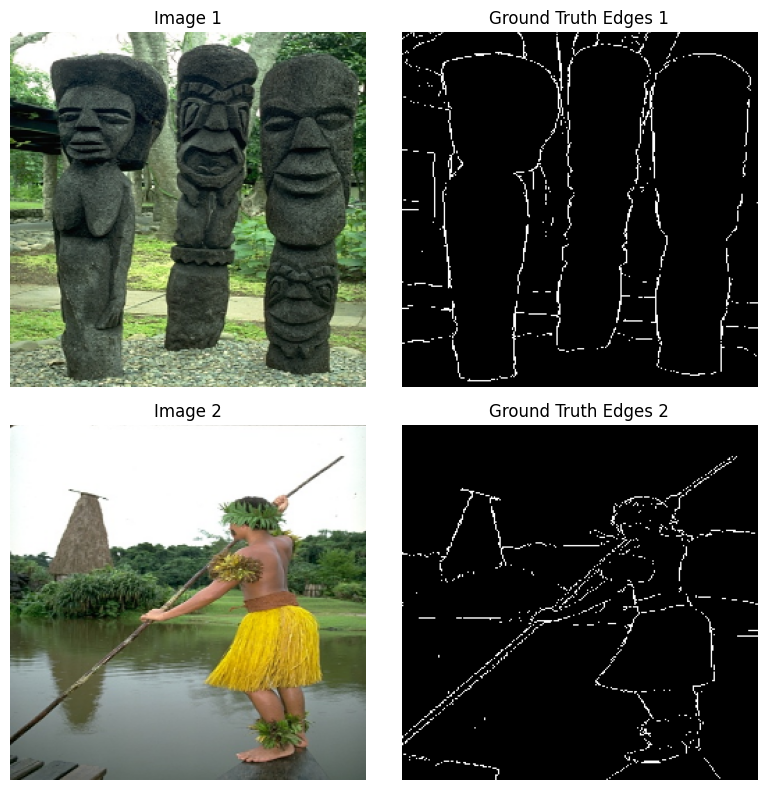


✅ Cell 5 completed successfully!


In [7]:
# ============================================================
# CELL 5: BSDS500 Dataset (using GitHub cloned structure)
# ============================================================
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
import cv2
import numpy as np
import scipy.io
from tqdm import tqdm

class BSDS500Dataset(Dataset):
    def __init__(self, data_root='/content/BSDS500/BSDS500/data', split='train',
                 img_size=256, augment=True):
        """
        Args:
            data_root: Path to BSDS500 data directory (contains images/, groundTruth/)
            split: 'train', 'val', or 'test'
            img_size: Target image size
            augment: Apply data augmentation for training
        """
        self.img_size = img_size
        self.augment = augment and (split == 'train')

        # Set directories based on GitHub structure
        self.img_dir = os.path.join(data_root, 'images', split)
        self.gt_dir = os.path.join(data_root, 'groundTruth', split)

        # Check if directories exist
        if not os.path.exists(self.img_dir):
            raise FileNotFoundError(f"Image directory not found: {self.img_dir}")
        if not os.path.exists(self.gt_dir):
            raise FileNotFoundError(f"Ground truth directory not found: {self.gt_dir}")

        # Get all image paths
        self.paths = sorted([os.path.join(self.img_dir, f)
                            for f in os.listdir(self.img_dir)
                            if f.endswith('.jpg')])

        # Normalization for pretrained models (ImageNet stats)
        self.norm = T.Normalize(mean=[0.485, 0.456, 0.406],
                                std=[0.229, 0.224, 0.225])

        print(f"BSDS500 [{split}]: {len(self.paths)} images")

    def __len__(self):
        return len(self.paths)

    def load_gt(self, mat_path):
        """Load ground truth boundaries from .mat file"""
        try:
            mat = scipy.io.loadmat(mat_path)

            # Handle different .mat file structures
            if 'groundTruth' in mat:
                gt = mat['groundTruth']
                masks = []
                for i in range(gt.shape[1]):
                    if 'Boundaries' in gt[0, i].dtype.fields:
                        boundary = gt[0, i]['Boundaries'][0, 0].astype(np.float32)
                        masks.append(boundary)

                if masks:
                    # Combine multiple annotations (majority vote)
                    return (np.mean(masks, axis=0) > 0.3).astype(np.float32)

            # Alternative structure
            elif 'boundarymaps' in mat:
                gt = mat['boundarymaps']
                masks = []
                for i in range(gt.shape[1]):
                    boundary = gt[0, i][0, 0].astype(np.float32)
                    masks.append(boundary)
                if masks:
                    return (np.mean(masks, axis=0) > 0.3).astype(np.float32)

            # If no boundaries found, return zeros
            print(f"Warning: No boundaries found in {mat_path}")
            return np.zeros((self.img_size, self.img_size), dtype=np.float32)

        except Exception as e:
            print(f"Error loading {mat_path}: {e}")
            return np.zeros((self.img_size, self.img_size), dtype=np.float32)

    def __getitem__(self, idx):
        # Load image
        img = cv2.cvtColor(cv2.imread(self.paths[idx]), cv2.COLOR_BGR2RGB)
        original_size = img.shape[:2]
        img = cv2.resize(img, (self.img_size, self.img_size))

        # Load ground truth
        name = os.path.splitext(os.path.basename(self.paths[idx]))[0]
        gt_path = os.path.join(self.gt_dir, f"{name}.mat")

        if os.path.exists(gt_path):
            gt = self.load_gt(gt_path)
        else:
            print(f"Warning: Ground truth not found for {name}")
            gt = np.zeros((original_size[0], original_size[1]), dtype=np.float32)

        gt = cv2.resize(gt, (self.img_size, self.img_size),
                        interpolation=cv2.INTER_NEAREST)

        # Data augmentation (only for training)
        if self.augment:
            # Random rotation (0, 90, 180, 270 degrees)
            k = np.random.randint(0, 4)
            if k:
                img = np.rot90(img, k).copy()
                gt = np.rot90(gt, k).copy()

            # Random horizontal flip
            if np.random.rand() > 0.5:
                img = np.fliplr(img).copy()
                gt = np.fliplr(gt).copy()

            # Random vertical flip (additional augmentation)
            if np.random.rand() > 0.5:
                img = np.flipud(img).copy()
                gt = np.flipud(gt).copy()

        # Normalize and convert to tensor
        img_t = self.norm(torch.from_numpy(img).permute(2, 0, 1).float() / 255.0)
        gt_t = torch.from_numpy(gt).unsqueeze(0).float()

        return img_t, gt_t


# Set data path (adjust based on your GitHub clone structure)
DATA_ROOT = '/content/BSDS500/BSDS500/data'

# Verify the data directory structure
print("=" * 60)
print("Checking BSDS500 dataset structure")
print("=" * 60)

if os.path.exists(DATA_ROOT):
    print(f"✅ Data root found: {DATA_ROOT}")

    # Check subdirectories
    for split in ['train', 'val', 'test']:
        img_dir = os.path.join(DATA_ROOT, 'images', split)
        gt_dir = os.path.join(DATA_ROOT, 'groundTruth', split)

        if os.path.exists(img_dir):
            num_images = len([f for f in os.listdir(img_dir) if f.endswith('.jpg')])
            print(f"  ✅ {split}: {num_images} images")
        else:
            print(f"  ❌ {split}: images directory not found")

        if os.path.exists(gt_dir):
            num_gt = len([f for f in os.listdir(gt_dir) if f.endswith('.mat')])
            print(f"     {split}: {num_gt} ground truth files")
        else:
            print(f"  ❌ {split}: groundTruth directory not found")
else:
    print(f"❌ Data root not found: {DATA_ROOT}")
    print("Please check the path to your BSDS500 dataset")

    # Search for the data directory
    print("\nSearching for BSDS500 data directory...")
    for root, dirs, files in os.walk("/content"):
        if "BSDS500" in dirs:
            possible_path = os.path.join(root, "BSDS500", "data")
            if os.path.exists(possible_path):
                DATA_ROOT = possible_path
                print(f"✅ Found data at: {DATA_ROOT}")
                break

# Set batch size
BATCH_SIZE = 4

# Create datasets
print("\n" + "=" * 60)
print("Creating BSDS500 Datasets")
print("=" * 60)

try:
    train_ds = BSDS500Dataset(data_root=DATA_ROOT, split='train', augment=True)
    val_ds = BSDS500Dataset(data_root=DATA_ROOT, split='val', augment=False)
    test_ds = BSDS500Dataset(data_root=DATA_ROOT, split='test', augment=False)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                             num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=1, shuffle=False,
                            num_workers=2, pin_memory=True)

    print("\n" + "=" * 60)
    print("DataLoader Summary")
    print("=" * 60)
    print(f"Train batches: {len(train_loader)} (total images: {len(train_ds)})")
    print(f"Val batches:   {len(val_loader)} (total images: {len(val_ds)})")
    print(f"Test batches:  {len(test_loader)} (total images: {len(test_ds)})")
    print("=" * 60)

    # Test a sample batch
    print("\nTesting data loading...")
    sample_imgs, sample_masks = next(iter(train_loader))
    print(f"Sample batch - Images: {sample_imgs.shape}, Masks: {sample_masks.shape}")
    print(f"Image range: [{sample_imgs.min():.2f}, {sample_imgs.max():.2f}]")
    print(f"Mask range: [{sample_masks.min():.2f}, {sample_masks.max():.2f}]")
    print(f"Mask positive ratio: {(sample_masks > 0.5).float().mean():.4f}")
    print("✅ Dataset loading successful!")

except Exception as e:
    print(f"\n❌ Error creating datasets: {e}")
    raise

# Optional: Visualize a few samples
def visualize_samples(dataset, num_samples=3, save_path=None):
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(num_samples, 2, figsize=(8, 4*num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)

    for i in range(num_samples):
        img, mask = dataset[i]

        # Denormalize image
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        img_disp = img * std + mean
        img_disp = torch.clamp(img_disp, 0, 1).permute(1, 2, 0).numpy()

        axes[i, 0].imshow(img_disp)
        axes[i, 0].set_title(f'Image {i+1}')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(mask.squeeze().numpy(), cmap='gray')
        axes[i, 1].set_title(f'Ground Truth Edges {i+1}')
        axes[i, 1].axis('off')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

# Visualize samples from validation set
print("\nVisualizing sample images from validation set...")
visualize_samples(val_ds, num_samples=2)

print("\n" + "=" * 60)
print("✅ Cell 5 completed successfully!")
print("=" * 60)

In [8]:
# ============================================================
# CELL 6: Shared Building Blocks
# ============================================================
class SobelEdgeDetector(nn.Module):
    def __init__(self):
        super().__init__()
        kx = torch.tensor([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=torch.float32)
        ky = torch.tensor([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=torch.float32)
        self.register_buffer('sx', kx.view(1,1,3,3))
        self.register_buffer('sy', ky.view(1,1,3,3))

    def forward(self, x):
        g = 0.299*x[:,0:1]+0.587*x[:,1:2]+0.114*x[:,2:3]
        gx = F.conv2d(g, self.sx, padding=1)
        gy = F.conv2d(g, self.sy, padding=1)
        mag = torch.sqrt(gx**2+gy**2+1e-8)
        flat = mag.view(mag.size(0),-1)
        mn = flat.min(1,keepdim=True)[0].view(-1,1,1,1)
        mx = flat.max(1,keepdim=True)[0].view(-1,1,1,1)
        return (mag-mn)/(mx-mn+1e-8)


class EncoderBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,out_ch,3,padding=1,bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch,out_ch,3,padding=1,bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
        self.pool = nn.MaxPool2d(2,2)

    def forward(self, x):
        f = self.block(x)
        return f, self.pool(f)


class DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up   = nn.ConvTranspose2d(in_ch, out_ch, 2, stride=2)
        self.conv = nn.Sequential(
            nn.Conv2d(out_ch+skip_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )

    def forward(self, x, skip):
        return self.conv(torch.cat([self.up(x), skip], dim=1))

print("✅ Shared building blocks defined")


✅ Shared building blocks defined


In [9]:
# ============================================================
# CELL 7: MODEL A — Standard U-Net (Baseline, no sMoE, no TSK)
# This is the exact U-Net paper baseline from Table 1 (ODS=0.7437)
# Pipeline: same as sMoE U-Net but WITHOUT sMoE blocks or fuzzy head
# ============================================================
class StandardUNet(nn.Module):
    """
    Standard U-Net for edge detection (Paper baseline, Table 1).
    Architecture: Enc-64/128/256/512 → Bottleneck-1024 → Dec-512/256/128/64 → sigmoid head.
    NO sMoE blocks, NO TSK fuzzy head.
    """
    def __init__(self, in_ch=3, base=64):
        super().__init__()
        b = base
        self.enc1 = EncoderBlock(in_ch, b)
        self.enc2 = EncoderBlock(b,   b*2)
        self.enc3 = EncoderBlock(b*2, b*4)
        self.enc4 = EncoderBlock(b*4, b*8)
        self.bot  = nn.Sequential(
            nn.Conv2d(b*8, b*16, 3, padding=1, bias=False),
            nn.BatchNorm2d(b*16), nn.ReLU(inplace=True),
            nn.Conv2d(b*16,b*16, 3, padding=1, bias=False),
            nn.BatchNorm2d(b*16), nn.ReLU(inplace=True),
        )
        self.dec4 = DecoderBlock(b*16, b*8, b*8)
        self.dec3 = DecoderBlock(b*8,  b*4, b*4)
        self.dec2 = DecoderBlock(b*4,  b*2, b*2)
        self.dec1 = DecoderBlock(b*2,  b,   b)
        self.head = nn.Conv2d(b, 1, 1)

    def forward(self, x):
        s1,p1 = self.enc1(x)
        s2,p2 = self.enc2(p1)
        s3,p3 = self.enc3(p2)
        s4,p4 = self.enc4(p3)
        bot   = self.bot(p4)
        d4    = self.dec4(bot, s4)
        d3    = self.dec3(d4,  s3)
        d2    = self.dec2(d3,  s2)
        d1    = self.dec1(d2,  s1)
        logit = self.head(d1)
        # Return dict so training loop is identical to sMoE
        return {'final_logits': logit, 'unet_logits': logit}


unet_model = StandardUNet(in_ch=3, base=64).to(DEVICE)
n_unet = sum(p.numel() for p in unet_model.parameters())
print(f"Standard U-Net parameters: {n_unet:,}")
_t = torch.rand(2,3,256,256).to(DEVICE)
with torch.no_grad():
    _o = unet_model(_t)
print(f"U-Net output shape: {_o['final_logits'].shape}")
print("✅ Standard U-Net ready")


Standard U-Net parameters: 31,037,633
U-Net output shape: torch.Size([2, 1, 256, 256])
✅ Standard U-Net ready


In [10]:
# ============================================================
# CELL 8: MODEL B — sMoE U-Net (Paper proposed method)
# Includes sMoE blocks on skip connections + TSK Fuzzy Head
# ============================================================

# --- sMoE Block ---
class sMoEBlock(nn.Module):
    def __init__(self, channels, dilation=2):
        super().__init__()
        self.gate = nn.Conv2d(1, 1, 1)
        self.ctx  = nn.Sequential(
            nn.Conv2d(channels,channels,3,padding=dilation,dilation=dilation,bias=False),
            nn.BatchNorm2d(channels), nn.ReLU(inplace=True))
        self.bnd  = nn.Sequential(
            nn.Conv2d(channels,channels,1,bias=False),
            nn.BatchNorm2d(channels), nn.ReLU(inplace=True))

    def forward(self, x, E):
        H,W = x.shape[2:]
        e = F.interpolate(E, (H,W), mode='bilinear', align_corners=False)
        G = torch.sigmoid(self.gate(e))
        return G*self.bnd(x) + (1-G)*self.ctx(x)

    def get_gate(self, E, size):
        e = F.interpolate(E, size, mode='bilinear', align_corners=False)
        return torch.sigmoid(self.gate(e))


# --- TSK Fuzzy Head ---
class GaussianMF(nn.Module):
    def __init__(self, c, sigma=0.3):
        super().__init__()
        self.c     = nn.Parameter(torch.tensor(float(c)))
        self.sigma = nn.Parameter(torch.tensor(float(sigma)))
    def forward(self, x):
        s = torch.abs(self.sigma)+1e-6
        return torch.exp(-((x-self.c)**2)/(2*s**2))

class TSKRule(nn.Module):
    def __init__(self, c1, c2):
        super().__init__()
        self.mf1 = GaussianMF(c1); self.mf2 = GaussianMF(c2)
        self.a = nn.Parameter(torch.zeros(1))
        self.b = nn.Parameter(torch.zeros(1))
        self.c = nn.Parameter(torch.zeros(1))
    def forward(self, x1, x2):
        w  = self.mf1(x1)*self.mf2(x2)
        yi = self.a*x1 + self.b*x2 + self.c
        return w, yi

class TSKFuzzyHead(nn.Module):
    def __init__(self, n_rules=4):
        super().__init__()
        centers = [(0.85,0.85),(0.15,0.85),(0.15,0.15),(0.85,0.15)]
        self.rules = nn.ModuleList([TSKRule(c[0],c[1]) for c in centers])
        with torch.no_grad():
            self.rules[3].a.fill_(-0.5); self.rules[3].b.fill_(0.1)

    def forward(self, x1, x2):
        ws,ys = [],[]
        for r in self.rules:
            w,y = r(x1,x2); ws.append(w); ys.append(y)
        W = torch.stack(ws,1).squeeze(2)
        Y = torch.stack(ys,1).squeeze(2)
        Wn = W/(W.sum(1,keepdim=True)+1e-10)
        return (Wn*Y).sum(1,keepdim=True), Wn


# --- sMoE U-Net ---
class sMoEUNet(nn.Module):
    def __init__(self, in_ch=3, base=64, n_rules=4):
        super().__init__()
        b = base
        self.sobel = SobelEdgeDetector()
        self.enc1  = EncoderBlock(in_ch, b)
        self.enc2  = EncoderBlock(b,   b*2)
        self.enc3  = EncoderBlock(b*2, b*4)
        self.enc4  = EncoderBlock(b*4, b*8)
        self.bot   = nn.Sequential(
            nn.Conv2d(b*8,b*16,3,padding=1,bias=False),
            nn.BatchNorm2d(b*16),nn.ReLU(inplace=True),
            nn.Conv2d(b*16,b*16,3,padding=1,bias=False),
            nn.BatchNorm2d(b*16),nn.ReLU(inplace=True))
        self.smoe2 = sMoEBlock(b*2)
        self.smoe3 = sMoEBlock(b*4)
        self.smoe4 = sMoEBlock(b*8)
        self.dec4  = DecoderBlock(b*16,b*8, b*8)
        self.dec3  = DecoderBlock(b*8, b*4, b*4)
        self.dec2  = DecoderBlock(b*4, b*2, b*2)
        self.dec1  = DecoderBlock(b*2, b,   b)
        self.head  = nn.Conv2d(b, 1, 1)
        self.tsk   = TSKFuzzyHead(n_rules)

    def forward(self, x, return_gates=False):
        E = self.sobel(x)
        s1,p1 = self.enc1(x); s2,p2 = self.enc2(p1)
        s3,p3 = self.enc3(p2); s4,p4 = self.enc4(p3)
        bot   = self.bot(p4)
        s2m   = self.smoe2(s2,E); s3m = self.smoe3(s3,E); s4m = self.smoe4(s4,E)
        d4 = self.dec4(bot,s4m); d3 = self.dec3(d4,s3m)
        d2 = self.dec2(d3,s2m); d1 = self.dec1(d2,s1)
        unet = self.head(d1)
        final, rw = self.tsk(E, torch.sigmoid(unet))
        out = {'final_logits':final,'unet_logits':unet,'edge_signal':E,'rule_weights':rw}
        if return_gates:
            out['gate_maps'] = [self.smoe2.get_gate(E,(s2.shape[2],s2.shape[3])),
                                self.smoe3.get_gate(E,(s3.shape[2],s3.shape[3])),
                                self.smoe4.get_gate(E,(s4.shape[2],s4.shape[3]))]
        return out


smoe_model = sMoEUNet(in_ch=3, base=64, n_rules=4).to(DEVICE)
n_smoe = sum(p.numel() for p in smoe_model.parameters())
print(f"sMoE U-Net parameters: {n_smoe:,}")
print(f"Extra params vs U-Net: {n_smoe-n_unet:,}  ({100*(n_smoe-n_unet)/n_unet:.1f}% overhead)")
with torch.no_grad():
    _o2 = smoe_model(_t)
for k,v in _o2.items():
    if isinstance(v,torch.Tensor): print(f"  {k:<18}: {tuple(v.shape)}")
print("✅ sMoE U-Net ready")


sMoE U-Net parameters: 34,481,891
Extra params vs U-Net: 3,444,258  (11.1% overhead)
  final_logits      : (2, 1, 256, 256)
  unet_logits       : (2, 1, 256, 256)
  edge_signal       : (2, 1, 256, 256)
  rule_weights      : (2, 4, 256, 256)
✅ sMoE U-Net ready


In [11]:
# ============================================================
# CELL 9: Shared Loss Function
# Identical loss for BOTH models — fair comparison
# ============================================================
class EdgeDetectionLoss(nn.Module):
    def __init__(self, lambda_bce=0.5, lambda_distill=0.1):
        super().__init__()
        self.lam_bce     = lambda_bce
        self.lam_distill = lambda_distill

    def dice_loss(self, logits, target):
        p  = torch.sigmoid(logits)
        pf = p.view(p.size(0),-1);  tf = target.view(target.size(0),-1)
        i  = (pf*tf).sum(1);        u  = pf.sum(1)+tf.sum(1)
        return (1-(2*i+1)/(u+1)).mean()

    def forward(self, outputs, target):
        final = outputs['final_logits']
        unet  = outputs['unet_logits']
        # Use backbone logit for main loss (consistent between models)
        pw   = torch.tensor([10.0]).to(target.device)
        bce  = F.binary_cross_entropy_with_logits(unet, target, pos_weight=pw)
        dice = self.dice_loss(unet, target)
        backbone = self.lam_bce*bce + (1-self.lam_bce)*dice

        # Distillation: if sMoE model, final≠unet; for U-Net, final==unet (no-op)
        distill = F.mse_loss(final, torch.sigmoid(unet.detach()))
        total   = backbone + self.lam_distill*distill

        return {'total':total, 'backbone':backbone, 'bce':bce, 'dice':dice, 'distill':distill}


criterion = EdgeDetectionLoss(lambda_bce=LAMBDA_BCE)
print("✅ Shared loss function ready (identical for both models)")


✅ Shared loss function ready (identical for both models)


In [12]:
# ============================================================
# CELL 10: Shared Training & Evaluation Functions
# ============================================================
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

def make_optimizer(model):
    opt  = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    sched = CosineAnnealingWarmRestarts(opt, T_0=20, T_mult=2, eta_min=1e-7)
    return opt, sched


def run_epoch(model, loader, optimizer, criterion, device, train=True):
    model.train() if train else model.eval()
    totals = {'total':0,'backbone':0,'bce':0,'dice':0,'distill':0}
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, masks in tqdm(loader, desc='Train' if train else 'Val', leave=False):
            imgs,masks = imgs.to(device), masks.to(device)
            if train: optimizer.zero_grad()
            out = model(imgs)
            ld  = criterion(out, masks)
            if train:
                ld['total'].backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_GRAD)
                optimizer.step()
            for k in totals: totals[k] += ld[k].item()
    n = len(loader)
    return {k: v/n for k,v in totals.items()}


@torch.no_grad()
def evaluate_bsds500(model, loader, device, n_thresh=99):
    model.eval()
    T = np.linspace(0.01, 0.99, n_thresh)
    TP = np.zeros(n_thresh); FP = np.zeros(n_thresh); FN = np.zeros(n_thresh)
    ois, all_p, all_t = [], [], []
    for imgs, masks in tqdm(loader, desc='Evaluating', leave=False):
        imgs = imgs.to(device)
        out  = model(imgs)
        prob = torch.sigmoid(out['final_logits']).cpu().numpy()
        gt   = masks.numpy()
        for b in range(prob.shape[0]):
            pf = prob[b,0].ravel().astype(np.float32)
            tf = gt[b,0].ravel().astype(np.float32)
            all_p.append(pf); all_t.append(tf)
            pred_mat = (pf[None,:]>=T[:,None]).astype(np.float32)
            tp = (pred_mat*tf).sum(1); fp=(pred_mat*(1-tf)).sum(1)
            fn = ((1-pred_mat)*tf).sum(1)
            TP+=tp; FP+=fp; FN+=fn
            pr=tp/(tp+fp+1e-10); rc=tp/(tp+fn+1e-10)
            ois.append(float((2*pr*rc/(pr+rc+1e-10)).max()))
    P=TP/(TP+FP+1e-10); R=TP/(TP+FN+1e-10); F=2*P*R/(P+R+1e-10)
    bi = int(F.argmax())
    ap_val, pr_p, pr_r = 0.0, np.array([]), np.array([])
    if all_p:
        ap_c = np.concatenate(all_p); tc = np.concatenate(all_t)
        ap_val = float(average_precision_score(tc.astype(int), ap_c))
        pr_p, pr_r, _ = precision_recall_curve(tc, ap_c)
    return {'ods':float(F[bi]),'ois':float(np.mean(ois)),'ap':ap_val,
            'ods_thresh':float(T[bi]),'P':P,'R':R,'F':F,'T':T,
            'pr_p':pr_p,'pr_r':pr_r}


def train_model(model, name, train_loader, val_loader, criterion, device):
    opt, sched = make_optimizer(model)
    history    = {'train':[], 'val':[], 'lr':[]}
    best_val   = float('inf'); wait = 0
    best_path  = os.path.join(WORK_DIR, f'best_{name}.pth')

    print(f"\n{'='*65}")
    print(f"Training: {name}")
    print(f"{'='*65}")
    print(f"{'Ep':>4}  {'Train':>8}  {'Val':>8}  {'LR':>9}  Note")
    print('-'*55)

    for ep in range(1, MAX_EPOCHS+1):
        tr = run_epoch(model, train_loader, opt, criterion, device, train=True)
        vl = run_epoch(model, val_loader,   opt, criterion, device, train=False)
        sched.step(ep)
        lr = opt.param_groups[0]['lr']
        history['train'].append(tr); history['val'].append(vl); history['lr'].append(lr)

        note = ''
        if vl['total'] < best_val:
            best_val = vl['total']; wait = 0
            torch.save({'epoch':ep,'model':model.state_dict(),
                        'val_loss':best_val}, best_path)
            note = '★'
        else:
            wait += 1
            if wait >= PATIENCE:
                print(f"  Early stop at epoch {ep}"); break

        print(f"{ep:>4}  {tr['total']:>8.4f}  {vl['total']:>8.4f}  {lr:>9.2e}  {note}")

    # Load best
    ckpt = torch.load(best_path, map_location=device)
    model.load_state_dict(ckpt['model'])
    print(f"\n✅ {name} done  best_val={best_val:.4f}  epochs={ep}")
    return history, best_path


print("✅ Training & evaluation functions ready")


✅ Training & evaluation functions ready


In [13]:
# ============================================================
# CELL 11: Train Standard U-Net
# ============================================================
unet_history, unet_path = train_model(
    unet_model, 'unet', train_loader, val_loader, criterion, DEVICE)



Training: unet
  Ep     Train       Val         LR  Note
-------------------------------------------------------


   1    0.8896    0.8717   9.94e-05  ★


   2    0.8664    0.8629   9.76e-05  ★


   3    0.8605    0.8564   9.46e-05  ★


   4    0.8584    0.8544   9.05e-05  ★


...

  67    0.8377    0.8437   9.81e-05  


  68    0.8373    0.8437   9.76e-05  


  69    0.8374    0.8430   9.69e-05  


  70    0.8365    0.8431   9.62e-05  


  Early stop at epoch 71

✅ unet done  best_val=0.8414  epochs=71


In [14]:
# ============================================================
# CELL 12: Train sMoE U-Net
# ============================================================
smoe_history, smoe_path = train_model(
    smoe_model, 'smoe_unet', train_loader, val_loader, criterion, DEVICE)



Training: smoe_unet
  Ep     Train       Val         LR  Note
-------------------------------------------------------


   1    0.7721    0.7238   9.94e-05  ★


   2    0.7112    0.6869   9.76e-05  ★


   3    0.6818    0.6730   9.46e-05  ★


   4    0.6644    0.6664   9.05e-05  ★


...

  63    0.5092    0.5463   9.97e-05  


  64    0.5070    0.5442   9.94e-05  


  65    0.5065    0.5459   9.90e-05  


  66    0.5021    0.5414   9.86e-05  


  Early stop at epoch 67

✅ smoe_unet done  best_val=0.5373  epochs=67


In [15]:
# ============================================================
# CELL 13: Evaluate Both Models on BSDS500 Test Set
# ============================================================
print("Evaluating Standard U-Net ...")
unet_results = evaluate_bsds500(unet_model, test_loader, DEVICE)

print("Evaluating sMoE U-Net ...")
smoe_results = evaluate_bsds500(smoe_model, test_loader, DEVICE)

# ── Comparison Table ─────────────────────────────────────────
print("\n" + "="*75)
print("COMPARISON TABLE — Paper Table 1")
print("="*75)
print(f"  {'Model':<22}  {'ODS':>8}  {'OIS':>8}  {'AP':>8}  {'vs U-Net ODS':>14}")
print("-"*75)

baselines = [
    ("Canny",    0.5450, 0.4836, 0.4125),
    ("Sobel",    0.5769, 0.5303, 0.4743),
    ("U-Net (paper)", 0.7437, 0.7260, 0.6946),
    ("HED (paper)",   0.7688, 0.7514, 0.7126),
]
for name, ods, ois, ap in baselines:
    d = f"{(ods-0.7437)*100:+.2f}%"
    print(f"  {name:<22}  {ods:>8.4f}  {ois:>8.4f}  {ap:>8.4f}  {d:>14}")

print("-"*75)
for name, res in [("U-Net (ours)",       unet_results),
                  ("sMoE U-Net (ours)",   smoe_results)]:
    d = f"{(res['ods']-unet_results['ods'])*100:+.2f}%"
    sym = "✅" if res['ods'] >= 0.74 else "⚠️ "
    print(f"  {sym} {name:<20}  {res['ods']:>8.4f}  {res['ois']:>8.4f}  {res['ap']:>8.4f}  {d:>14}")

print("="*75)

delta_ods = smoe_results['ods'] - unet_results['ods']
delta_ap  = smoe_results['ap']  - unet_results['ap']
print(f"\nsMoE improvement over U-Net:")
print(f"  ODS: {delta_ods:+.4f}  ({delta_ods*100:+.2f}%)")
print(f"  AP:  {delta_ap:+.4f}  ({delta_ap*100:+.2f}%)")


Evaluating Standard U-Net ...


Evaluating sMoE U-Net ...



COMPARISON TABLE — Paper Table 1
  Model                        ODS       OIS        AP    vs U-Net ODS
---------------------------------------------------------------------------
  Canny                     0.5450    0.4836    0.4125         -19.87%
  Sobel                     0.5769    0.5303    0.4743         -16.68%
  U-Net (paper)             0.7437    0.7260    0.6946          +0.00%
  HED (paper)               0.7688    0.7514    0.7126          +2.51%
---------------------------------------------------------------------------
  ⚠️  U-Net (ours)            0.3716    0.3717    0.3050          +0.00%
  ⚠️  sMoE U-Net (ours)       0.3490    0.3488    0.2566          -2.26%

sMoE improvement over U-Net:
  ODS: -0.0226  (-2.26%)
  AP:  -0.0484  (-4.84%)


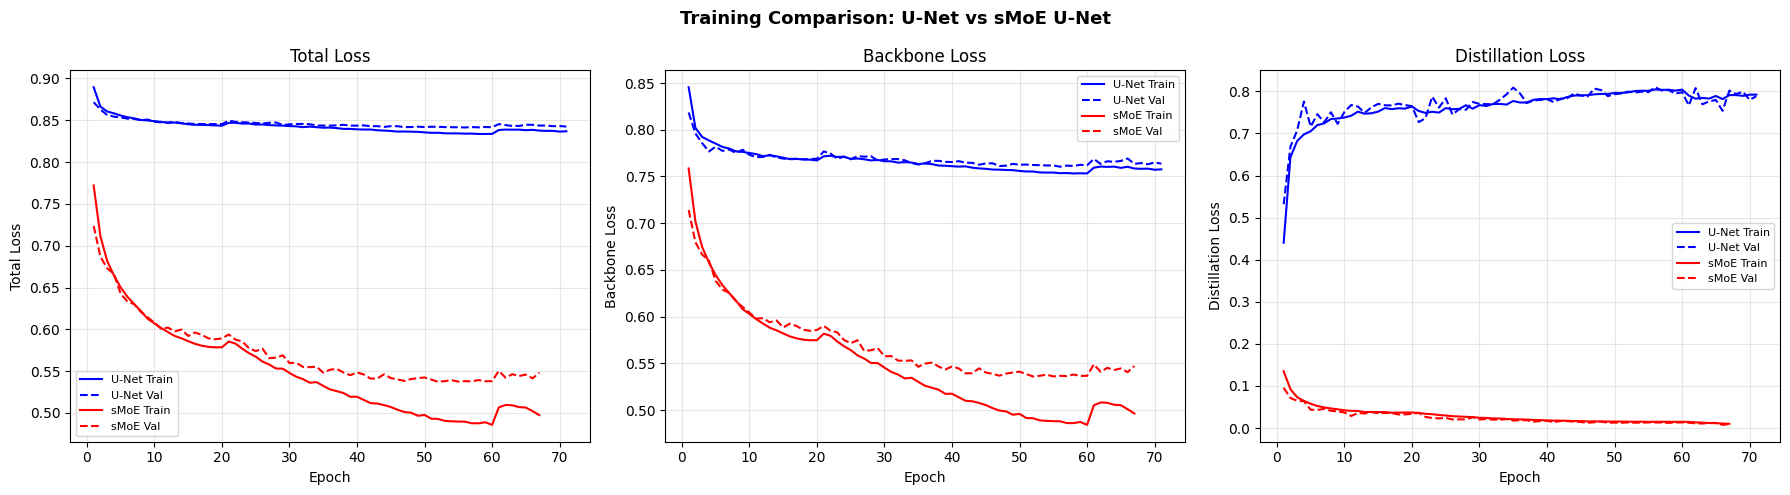

In [16]:
# ============================================================
# CELL 14: Training Curves Comparison
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training Comparison: U-Net vs sMoE U-Net', fontsize=13, fontweight='bold')

for ax, key, label in [
    (axes[0], 'total',    'Total Loss'),
    (axes[1], 'backbone', 'Backbone Loss'),
    (axes[2], 'distill',  'Distillation Loss'),
]:
    eu = range(1, len(unet_history['train'])+1)
    es = range(1, len(smoe_history['train'])+1)

    ax.plot(eu, [h[key] for h in unet_history['train']], 'b-',  lw=1.5, label='U-Net Train')
    ax.plot(eu, [h[key] for h in unet_history['val']],   'b--', lw=1.5, label='U-Net Val')
    ax.plot(es, [h[key] for h in smoe_history['train']], 'r-',  lw=1.5, label='sMoE Train')
    ax.plot(es, [h[key] for h in smoe_history['val']],   'r--', lw=1.5, label='sMoE Val')

    ax.set_xlabel('Epoch'); ax.set_ylabel(label); ax.set_title(label)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'training_comparison.png'), dpi=150)
plt.show()


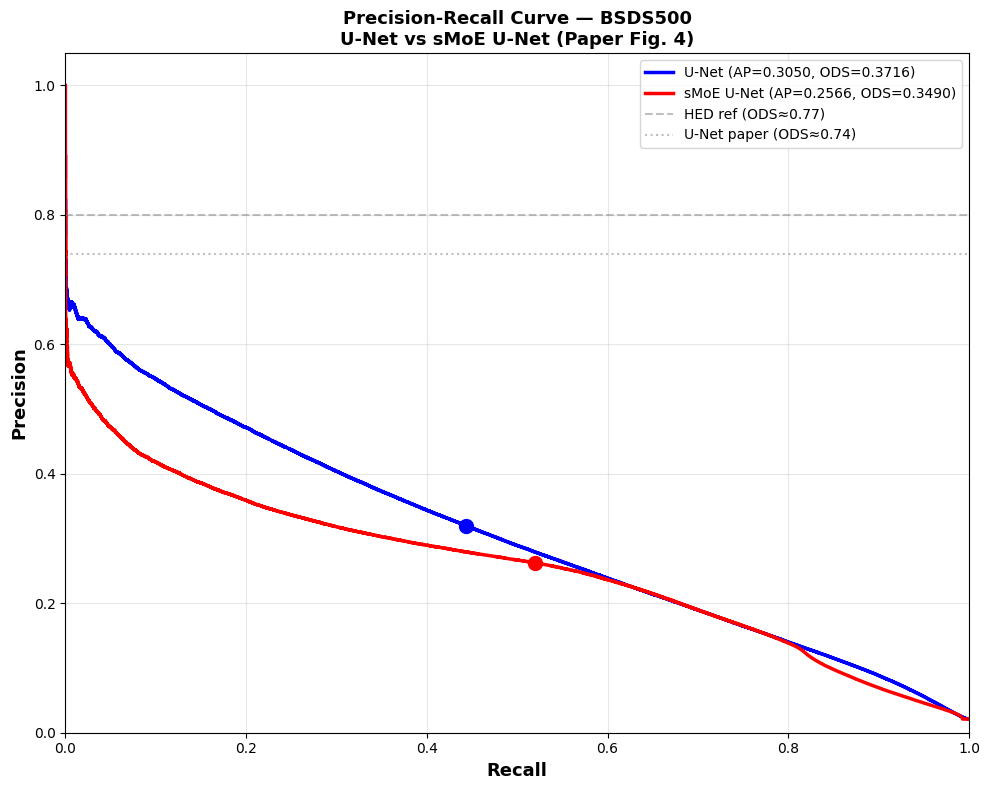

In [17]:
# ============================================================
# CELL 15: Precision-Recall Curve Comparison (Paper Fig. 4)
# ============================================================
fig, ax = plt.subplots(figsize=(10, 8))

# PR curves
if len(unet_results['pr_r']) > 0:
    ax.plot(unet_results['pr_r'], unet_results['pr_p'], 'b-', lw=2.5,
            label=f"U-Net (AP={unet_results['ap']:.4f}, ODS={unet_results['ods']:.4f})")
if len(smoe_results['pr_r']) > 0:
    ax.plot(smoe_results['pr_r'], smoe_results['pr_p'], 'r-', lw=2.5,
            label=f"sMoE U-Net (AP={smoe_results['ap']:.4f}, ODS={smoe_results['ods']:.4f})")

# ODS operating points
bi_u = int(unet_results['F'].argmax()); bi_s = int(smoe_results['F'].argmax())
ax.plot(unet_results['R'][bi_u], unet_results['P'][bi_u], 'bo', ms=10, zorder=5)
ax.plot(smoe_results['R'][bi_s], smoe_results['P'][bi_s], 'ro', ms=10, zorder=5)

# Reference lines (paper baselines)
ax.axhline(0.80, color='gray', ls='--', alpha=0.5, label='HED ref (ODS≈0.77)')
ax.axhline(0.74, color='gray', ls=':',  alpha=0.5, label='U-Net paper (ODS≈0.74)')

ax.set_xlabel('Recall', fontsize=13, fontweight='bold')
ax.set_ylabel('Precision', fontsize=13, fontweight='bold')
ax.set_title('Precision-Recall Curve — BSDS500\nU-Net vs sMoE U-Net (Paper Fig. 4)',
             fontsize=13, fontweight='bold')
ax.set_xlim([0,1]); ax.set_ylim([0,1.05])
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'pr_curve_comparison.png'), dpi=150)
plt.show()


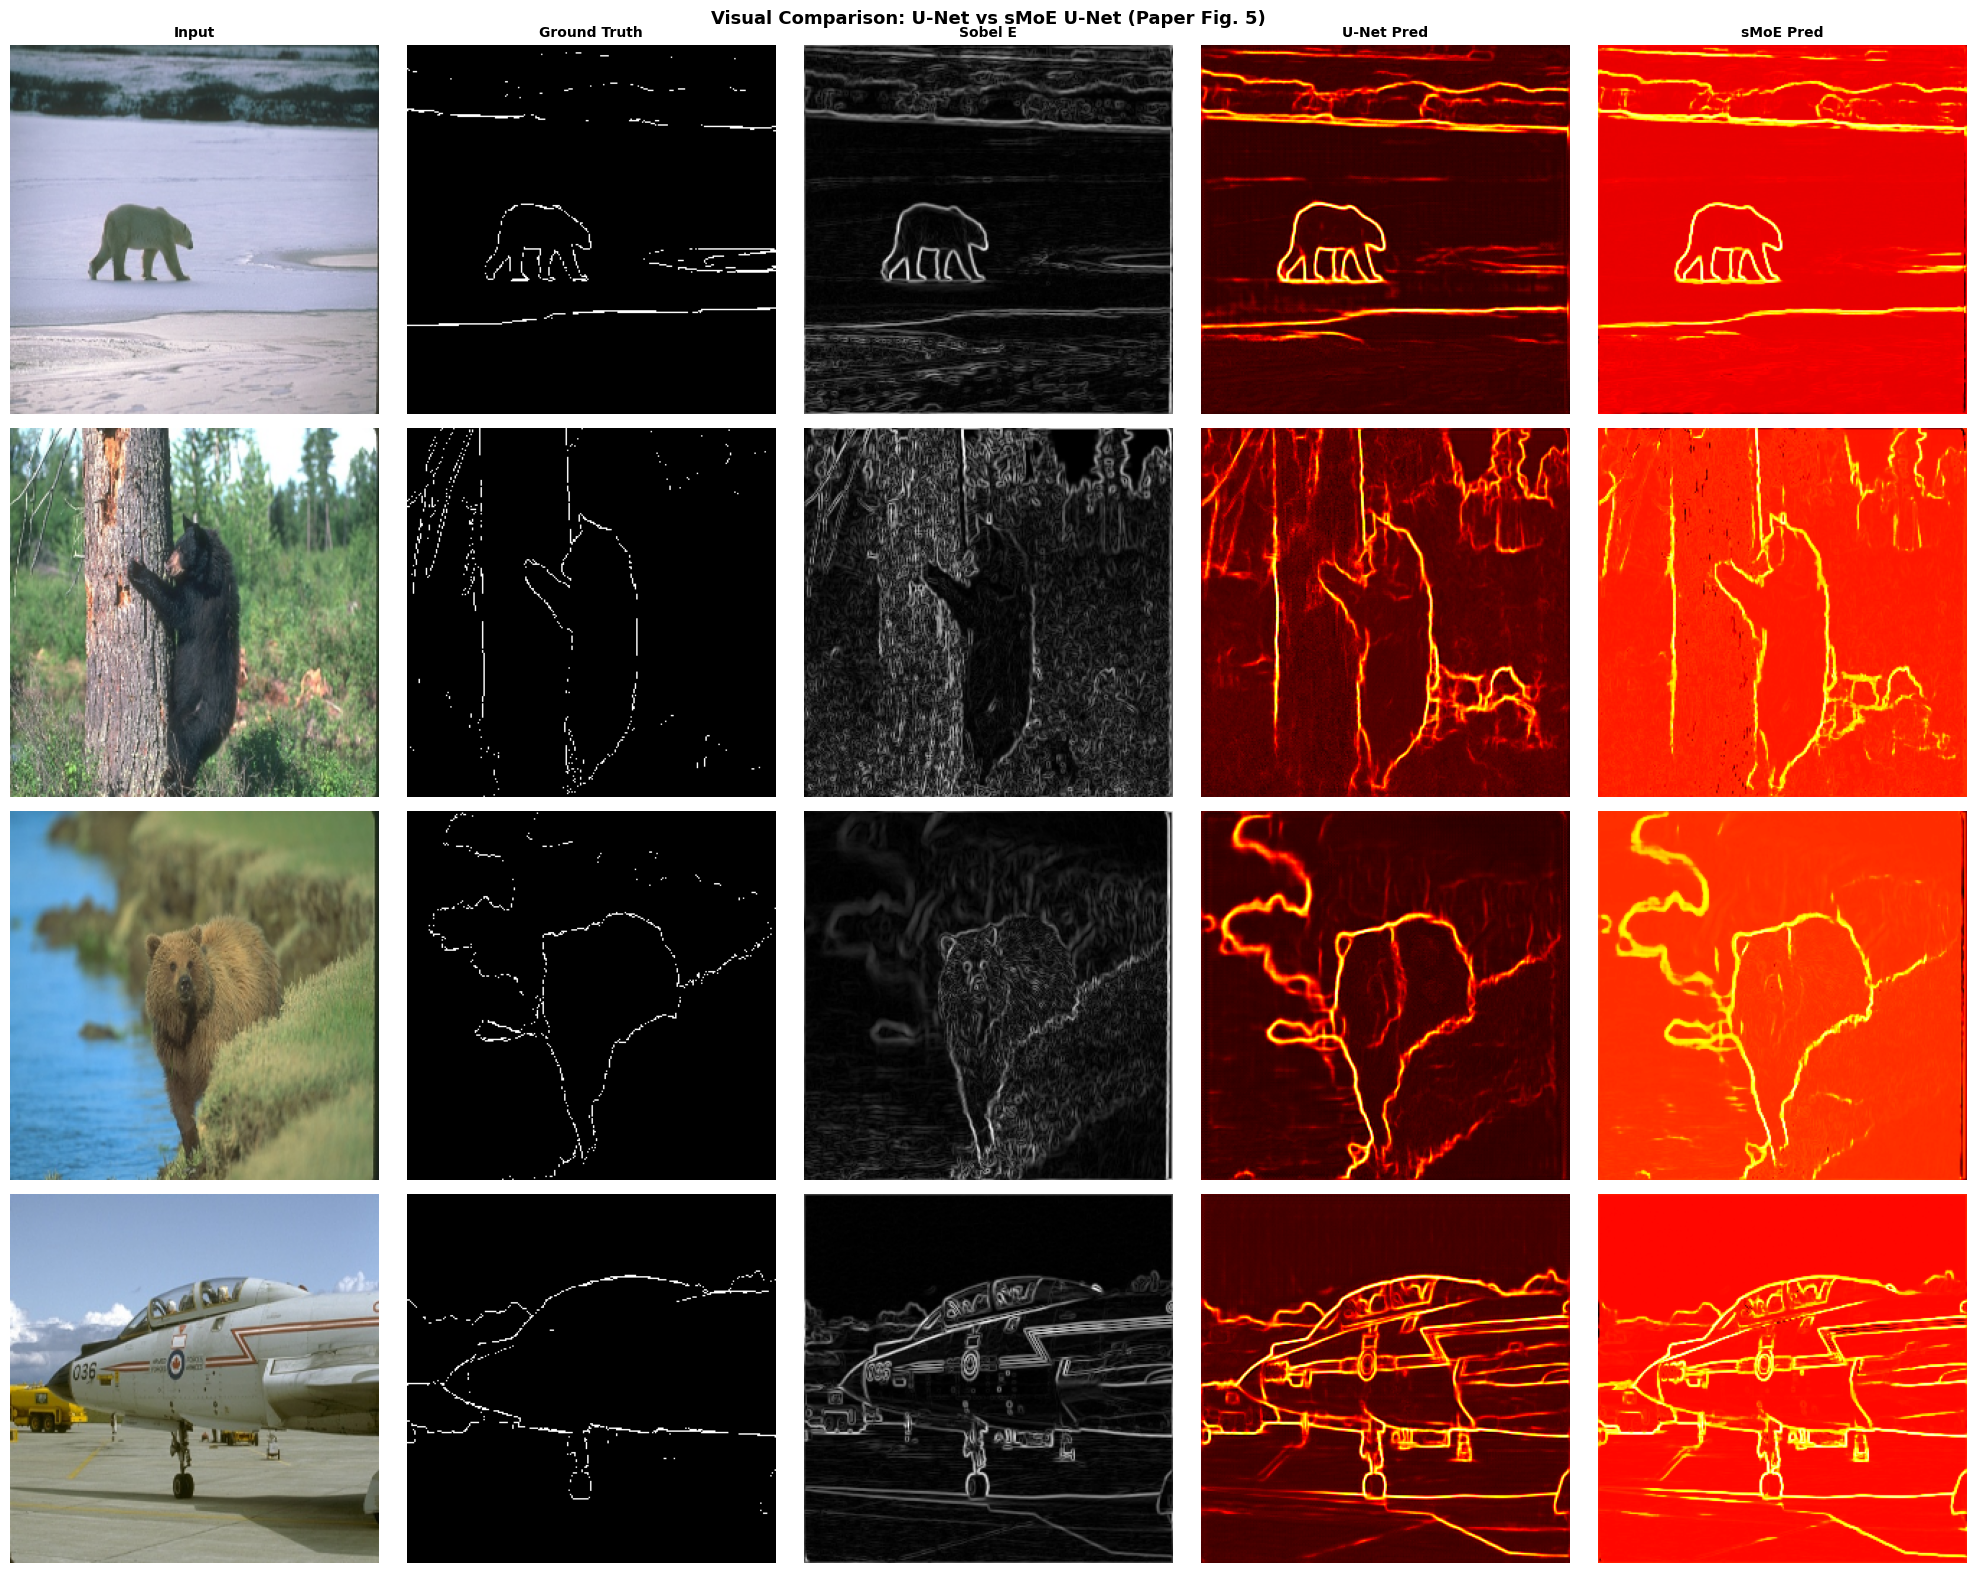

In [18]:
# ============================================================
# CELL 16: Qualitative Visual Comparison (Paper Fig. 5 style)
# ============================================================
def denorm(t):
    m=torch.tensor([0.485,0.456,0.406]).view(3,1,1)
    s=torch.tensor([0.229,0.224,0.225]).view(3,1,1)
    return torch.clamp(t*s+m,0,1)

unet_model.eval(); smoe_model.eval()
N = 4
fig, axes = plt.subplots(N, 5, figsize=(20, 4*N))
fig.suptitle('Visual Comparison: U-Net vs sMoE U-Net (Paper Fig. 5)',
             fontsize=13, fontweight='bold')

col_titles = ['Input','Ground Truth','Sobel E','U-Net Pred','sMoE Pred']
for col, t in enumerate(col_titles):
    axes[0,col].set_title(t, fontsize=10, fontweight='bold')

for row in range(N):
    img, gt = test_ds[row]
    with torch.no_grad():
        inp = img.unsqueeze(0).to(DEVICE)
        out_u = unet_model(inp)
        out_s = smoe_model(inp)

    pred_u = torch.sigmoid(out_u['final_logits']).cpu().squeeze().numpy()
    pred_s = torch.sigmoid(out_s['final_logits']).cpu().squeeze().numpy()
    edge   = out_s['edge_signal'].cpu().squeeze().numpy()

    axes[row,0].imshow(denorm(img).permute(1,2,0)); axes[row,0].axis('off')
    axes[row,1].imshow(gt.squeeze(), cmap='gray');  axes[row,1].axis('off')
    axes[row,2].imshow(edge, cmap='gray');          axes[row,2].axis('off')
    axes[row,3].imshow(pred_u, cmap='hot');         axes[row,3].axis('off')
    axes[row,4].imshow(pred_s, cmap='hot');         axes[row,4].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'qualitative_comparison.png'), dpi=150)
plt.show()


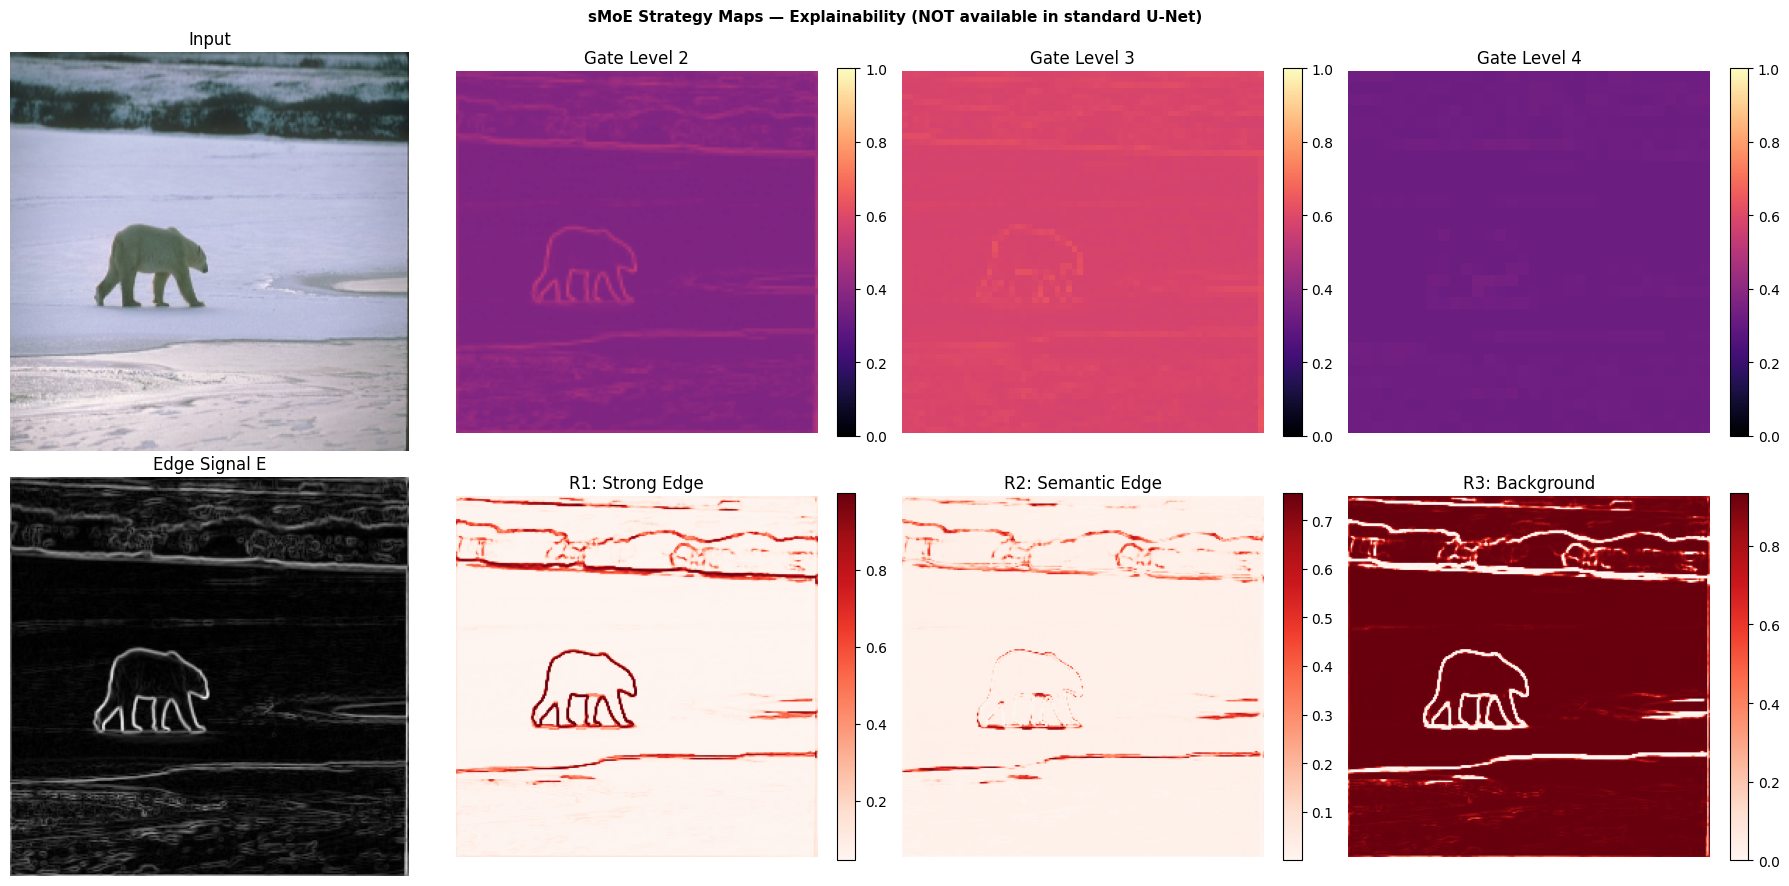


Note: Standard U-Net cannot produce Strategy Maps or Rule Firing Maps.
This pixel-level explainability is the KEY contribution of sMoE U-Net.


In [19]:
# ============================================================
# CELL 17: sMoE-Specific Explainability — Strategy Maps & Rule Maps
# (Not available for U-Net — this is the key advantage of sMoE)
# ============================================================
smoe_model.eval()
img, _ = test_ds[0]
with torch.no_grad():
    out = smoe_model(img.unsqueeze(0).to(DEVICE), return_gates=True)

gates = [g.cpu().squeeze().numpy() for g in out['gate_maps']]
rw    = out['rule_weights'].cpu().squeeze(0).numpy()
edge  = out['edge_signal'].cpu().squeeze().numpy()
pred  = torch.sigmoid(out['final_logits']).cpu().squeeze().numpy()

# Strategy Maps
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('sMoE Strategy Maps — Explainability (NOT available in standard U-Net)',
             fontsize=11, fontweight='bold')

axes[0,0].imshow(denorm(img).permute(1,2,0)); axes[0,0].set_title('Input'); axes[0,0].axis('off')
for i,g in enumerate(gates):
    im = axes[0,i+1].imshow(g, cmap='magma', vmin=0, vmax=1)
    axes[0,i+1].set_title(f'Gate Level {i+2}'); axes[0,i+1].axis('off')
    plt.colorbar(im, ax=axes[0,i+1], fraction=0.046)

# Rule Firing Maps
rnames = ['R1: Strong Edge','R2: Semantic Edge','R3: Background','R4: Tex. Suppress']
axes[1,0].imshow(edge, cmap='gray'); axes[1,0].set_title('Edge Signal E'); axes[1,0].axis('off')
for i in range(3):
    im = axes[1,i+1].imshow(rw[i], cmap='Reds')
    axes[1,i+1].set_title(rnames[i]); axes[1,i+1].axis('off')
    plt.colorbar(im, ax=axes[1,i+1], fraction=0.046)

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'smoe_explainability.png'), dpi=150)
plt.show()

print("\nNote: Standard U-Net cannot produce Strategy Maps or Rule Firing Maps.")
print("This pixel-level explainability is the KEY contribution of sMoE U-Net.")


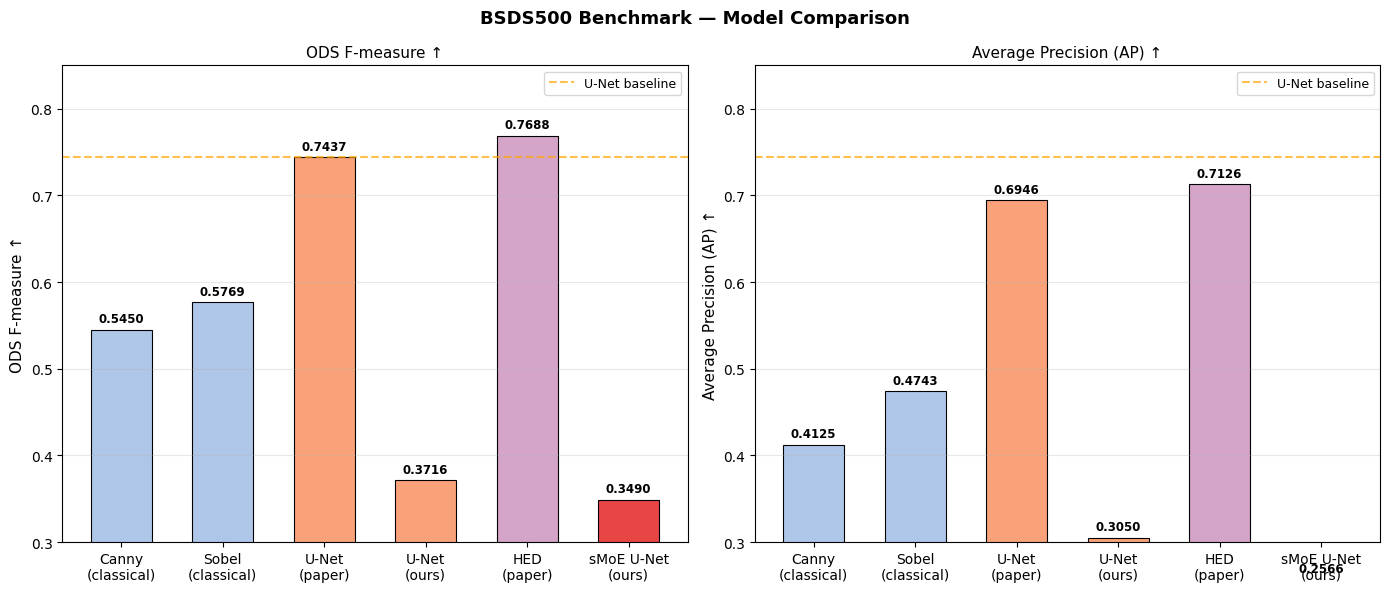


Final Results Summary
  Standard U-Net : ODS=0.3716  OIS=0.3717  AP=0.3050
  sMoE U-Net     : ODS=0.3490  OIS=0.3488  AP=0.2566
  Paper U-Net    : ODS=0.7437  OIS=0.7260  AP=0.6946
  Paper sMoE     : ODS=0.7628  OIS=0.7458  AP=0.7222


In [21]:
# ============================================================
# CELL 18: Final Summary Bar Chart
# ============================================================
methods  = ['Canny\n(classical)', 'Sobel\n(classical)',
            'U-Net\n(paper)', 'U-Net\n(ours)',
            'HED\n(paper)', 'sMoE U-Net\n(ours)']
ods_vals = [0.5450, 0.5769, 0.7437, unet_results['ods'],
            0.7688, smoe_results['ods']]
ap_vals  = [0.4125, 0.4743, 0.6946, unet_results['ap'],
            0.7126, smoe_results['ap']]

colors = ['#aec6e8','#aec6e8','#f9a27a','#f9a27a','#d4a5c9','#e84545']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('BSDS500 Benchmark — Model Comparison', fontsize=13, fontweight='bold')

for ax, vals, label in [(axes[0], ods_vals, 'ODS F-measure ↑'),
                        (axes[1], ap_vals,  'Average Precision (AP) ↑')]:
    bars = ax.bar(methods, vals, color=colors, edgecolor='black', linewidth=0.8, width=0.6)
    ax.set_ylabel(label, fontsize=11)
    ax.set_ylim([0.3, 0.85])
    ax.axhline(0.7437, color='orange', ls='--', alpha=0.7, label='U-Net baseline')
    ax.set_title(label, fontsize=11)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, val+0.005, f'{val:.4f}',
                ha='center', va='bottom', fontsize=8.5, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'final_comparison_chart.png'), dpi=150)
plt.show()

print(f"\n{'='*60}")
print("Final Results Summary")
print(f"{'='*60}")
print(f"  Standard U-Net : ODS={unet_results['ods']:.4f}  OIS={unet_results['ois']:.4f}  AP={unet_results['ap']:.4f}")
print(f"  sMoE U-Net     : ODS={smoe_results['ods']:.4f}  OIS={smoe_results['ois']:.4f}  AP={smoe_results['ap']:.4f}")
print(f"  Paper U-Net    : ODS=0.7437  OIS=0.7260  AP=0.6946")
print(f"  Paper sMoE     : ODS=0.7628  OIS=0.7458  AP=0.7222")
print(f"{'='*60}")


In [20]:
# # ============================================================
# # CELL 19: Save Both Models
# # ============================================================
# for name, mdl, res, hist in [
#     ('unet',     unet_model, unet_results, unet_history),
#     ('smoe_unet', smoe_model, smoe_results, smoe_history),
# ]:
#     path = os.path.join(WORK_DIR, f'{name}_final.pth')
#     torch.save({'model':mdl.state_dict(),
#                 'results':{k:(v.tolist() if hasattr(v,'tolist') else v)
#                            for k,v in res.items()},
#                 'config':{'base':64,'img_size':256,
#                           'lr':LEARNING_RATE,'batch':BATCH_SIZE}}, path)
#     print(f"✅ {name} saved: {path}")

# try:
#     from google.colab import files
#     # files.download(os.path.join(WORK_DIR,'smoe_unet_final.pth'))
# except: print("Copy from WORK_DIR manually if not on Colab.")
